# NB11 — External Validity: Dataset Description, Class Merging, and Before/After Deduplication

This notebook produces everything needed for a properly documented external-validity
section:

1. A description of the external dataset (Nirob et al., Lychee Leaf Disease Dataset,
   Mendeley DOI 10.17632/jb7w4452pg.1): per-class image counts and a sample-image
   figure, mirroring how BDLitchi itself is described in the paper.
2. A fully documented class-merging procedure: which of the external dataset's classes
   map onto which of BDLitchi's 11 classes, and why (or why not).
3. Two accuracy numbers per model, not one:
   - **open-set accuracy** — the model predicts freely among all 11 BDLitchi classes;
     a prediction that lands on a class absent from the external dataset counts as
     wrong. This is what the paper currently reports (0.459).
   - **closed-set (restricted) accuracy** — the same filtered test images, but the
     model's decision is restricted to just the 3 classes that exist in both
     datasets (Dried Leaf, Healthy Leaf, Leaf Blight Disease). This is the fairer
     like-for-like comparison and will read higher, because it removes the penalty
     for predicting a class that was never a valid option to begin with.
4. A before/after deduplication comparison: the same external evaluation run through
   both the **naive-split-trained** and **specimen-disjoint-trained** ResNet-50
   checkpoints (both already exist from NB02's leakage ablation — no retraining
   needed here), to see whether a leakage-inflated model also looks better, or
   worse, on genuinely external data.

Runtime: a few minutes (inference only, no training). No GPU strictly required, but
one speeds up the forward passes.


In [1]:
# ===== Imports =====
import os, json, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms

from sklearn.metrics import f1_score, confusion_matrix

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


In [2]:

EXTERNAL_DIR = Path('/kaggle/input/datasets/maruf170102/lychee-disease-dataset/Lychee Disease Dataset')  


CHECKPOINTS = [
    {'tag': 'ResNet50_group_seed42', 'arch': 'ResNet50', 'condition': 'specimen-disjoint',
     'path': '/kaggle/input/datasets/maruf170102/nb02-corrected-leakage-ablation/revision_ablation/checkpoints/ResNet50_group_seed42.pt'},
    {'tag': 'ResNet50_naive_seed42', 'arch': 'ResNet50', 'condition': 'naive',
     'path': '/kaggle/input/datasets/maruf170102/nb02-corrected-leakage-ablation/revision_ablation/checkpoints/ResNet50_naive_seed42.pt'},
]

OUT_DIR = Path('/kaggle/working/revision_external'); OUT_DIR.mkdir(parents=True, exist_ok=True)

# The 11 BDLitchi classes, alphabetical (matches the label encoder used for every
# checkpoint trained in this project, and Figure 2's ordering in the paper).
CLASSES = ['Black Spot', 'Burned Leaf', 'Dried Leaf', 'Fungal Stripe Damage',
           'Healthy Leaf', 'Insect Chewing Damage', 'Leaf Blight Disease',
           'Pest-Affected Dry Leaf', 'Red Rust Disease', 'White Spot',
           'Yellow Mosaic Virus']
NC = len(CLASSES)
label2idx = {c: i for i, c in enumerate(CLASSES)}

# --- external class name -> BDLitchi class name --------------------------------
# Nirob et al. (10.17632/jb7w4452pg.1) ships 10 classes. Only three map onto
# BDLitchi with confidence, on name alone: identical or near-identical wording,
# no morphology judgement call needed. The other candidates below are commented
# out deliberately — mapping "Fungal Leaf Spot" to "Fungal Stripe Damage", say,
# would conflate a spot pattern with a stripe pattern on visual guesswork alone.
# Three defensible classes beat seven speculative ones: a reader can check a
# three-item mapping by eye, and a wrong guess anywhere in the mapping would
# discredit the entire external-validity result, not just one class.
CLASS_MAP = {
    'Healthy Leaf': 'Healthy Leaf',            # exact
    'Leaf Blight': 'Leaf Blight Disease',      # exact, naming variant only
    'Dry Leaf': 'Dried Leaf',                  # near-certain
    # 'Fungal Leaf Spot': 'Fungal Stripe Damage',  # enable ONLY after eyeballing images
    # 'Anthrax Leaf':     'Black Spot',
    # 'Felt Leaf':        'Red Rust Disease',
}
SHARED_CLASSES = sorted(set(CLASS_MAP.values()))
print('Configured checkpoints:', [c['tag'] for c in CHECKPOINTS])
print('Shared classes (external -> BDLitchi):', CLASS_MAP)


Configured checkpoints: ['ResNet50_group_seed42', 'ResNet50_naive_seed42']
Shared classes (external -> BDLitchi): {'Healthy Leaf': 'Healthy Leaf', 'Leaf Blight': 'Leaf Blight Disease', 'Dry Leaf': 'Dried Leaf'}


In [3]:
# ===== 1. Scan the external dataset: confirm folder names, build class-distribution table =====
assert EXTERNAL_DIR.exists(), f'EXTERNAL_DIR not found: {EXTERNAL_DIR} -- edit the Config cell above.'

ext_classes = sorted([d.name for d in EXTERNAL_DIR.iterdir() if d.is_dir()])
rows = []
for ec in ext_classes:
    files = [p for p in (EXTERNAL_DIR / ec).glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp', '.webp')]
    rows.append({'external_class': ec, 'images': len(files),
                 'mapped_to': CLASS_MAP.get(ec, '(unmapped -- excluded from evaluation)')})

dist = pd.DataFrame(rows).sort_values('images', ascending=False).reset_index(drop=True)
print(dist.to_string(index=False))
print(f'\nTotal external images: {dist.images.sum()}')
print(f'Images in mapped (shared) classes: {dist[dist.mapped_to.isin(SHARED_CLASSES)].images.sum()}')

dist.to_csv(OUT_DIR / 'external_class_distribution.csv', index=False)

# --- LaTeX table ---
tex_rows = '\n'.join(
    f"{r.external_class} & {r.images} & {r.mapped_to} \\\\"
    for r in dist.itertuples()
)
tex = r'''\begin{table}[H]
\centering
\caption{Per-class composition of the external validation dataset (Nirob et al., Lychee Leaf Disease Dataset, Mendeley DOI 10.17632/jb7w4452pg.1), an independently collected Bangladeshi corpus used for zero-shot transfer (Section~\ref{sec:results_external}). ``Mapped to'' gives the BDLitchi class each external class is treated as equivalent to; classes marked unmapped are excluded from the evaluation set entirely, not merely from scoring.}
\label{tab:external_dataset_composition}
\small
\begin{tabular}{lrl}
\toprule
External class & Images & Mapped to (BDLitchi class) \\
\midrule
''' + tex_rows + r'''
\bottomrule
\end{tabular}
\end{table}
'''
open(OUT_DIR / 'table_external_dataset_composition.tex', 'w').write(tex)
print('\nSaved external_class_distribution.csv and table_external_dataset_composition.tex')


  external_class  images                              mapped_to
    Healthy Leaf     628                           Healthy Leaf
       Leaf Gall     622 (unmapped -- excluded from evaluation)
     Leaf Blight     592                    Leaf Blight Disease
Fungal Leaf Spot     574 (unmapped -- excluded from evaluation)
       Felt Leaf     382 (unmapped -- excluded from evaluation)
        Dry Leaf     381                             Dried Leaf
       Curl Leaf     180 (unmapped -- excluded from evaluation)
    Anthrax Leaf     148 (unmapped -- excluded from evaluation)
 Bituminous Leaf     138 (unmapped -- excluded from evaluation)
 Deficiency Leaf     123 (unmapped -- excluded from evaluation)

Total external images: 3768
Images in mapped (shared) classes: 1601

Saved external_class_distribution.csv and table_external_dataset_composition.tex


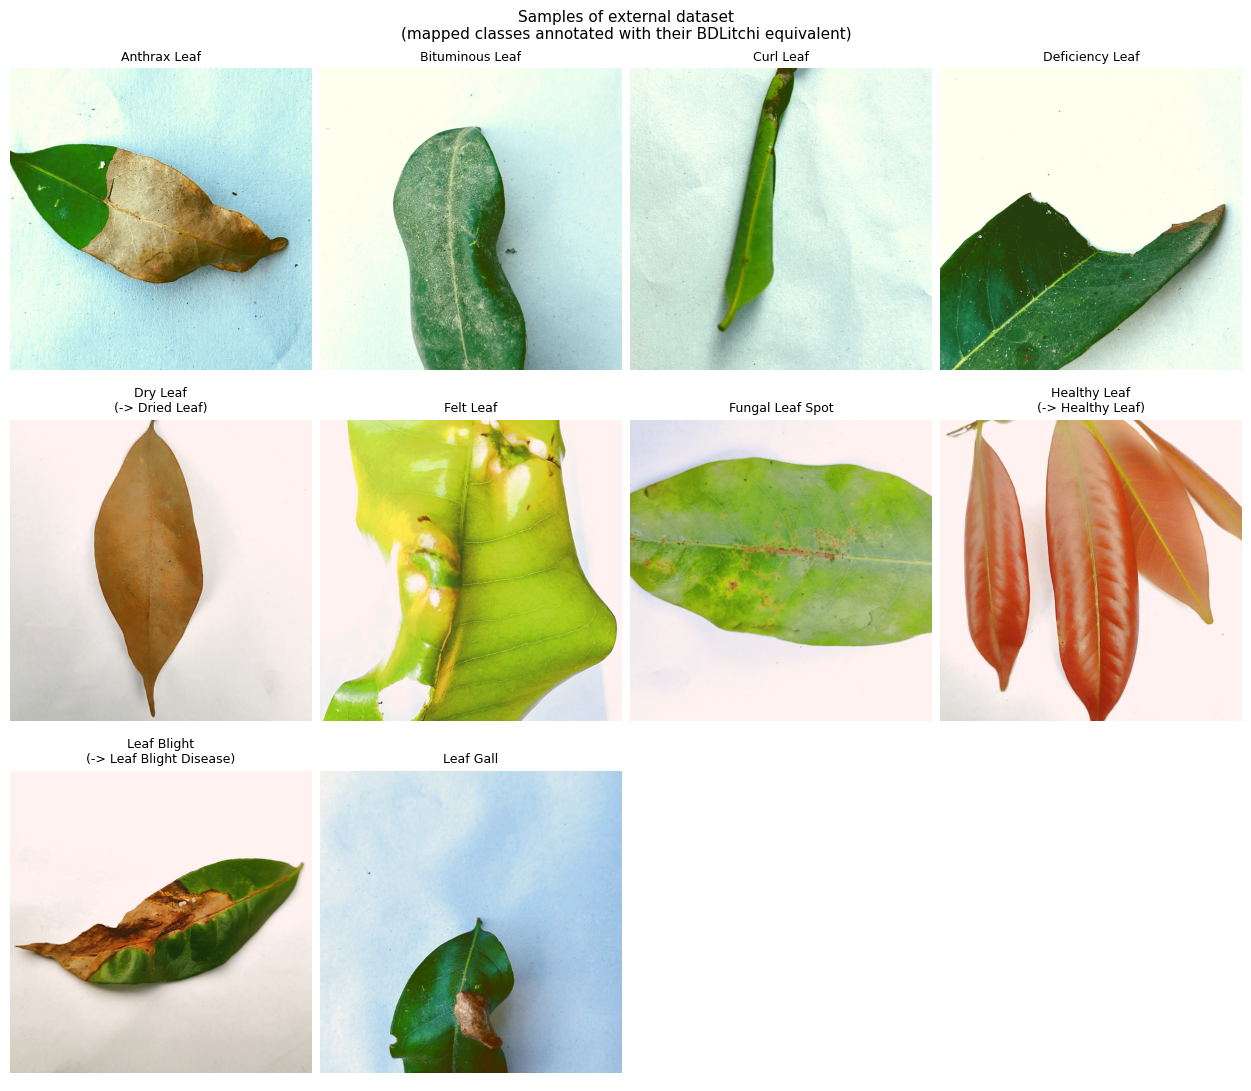

Saved /kaggle/working/revision_external/fig_external_sample_images.png


In [4]:
# ===== 2. Sample-image figure: one representative image per external class =====
n_classes = len(ext_classes)
ncols = 4
nrows = int(np.ceil(n_classes / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 3.6 * nrows),
                          constrained_layout=True)
axes = np.atleast_1d(axes).flatten()

for i, ec in enumerate(ext_classes):
    files = sorted([p for p in (EXTERNAL_DIR / ec).glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp', '.webp')])
    ax = axes[i]
    if files:
        img = Image.open(files[0]).convert('RGB')
        ax.imshow(img)
    label = ec if ec not in CLASS_MAP else f'{ec}\n(-> {CLASS_MAP[ec]})'
    ax.set_title(label, fontsize=9)
    ax.axis('off')
for j in range(n_classes, len(axes)):
    axes[j].axis('off')

fig.suptitle('Samples of external dataset\n(mapped classes annotated with their BDLitchi equivalent)',
             fontsize=11)
fig_path = OUT_DIR / 'fig_external_sample_images.png'
plt.savefig(fig_path, dpi=200)
plt.show()
print('Saved', fig_path)


In [5]:
# ===== 3. Build the filtered external evaluation set (mapped classes only) =====
rows = []
for ec in ext_classes:
    if ec not in CLASS_MAP:
        continue
    for p_ in (EXTERNAL_DIR / ec).glob('*'):
        if p_.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp', '.webp'):
            rows.append({'filepath': str(p_), 'filename': p_.name, 'label': CLASS_MAP[ec]})

ext = pd.DataFrame(rows)
print(f'External evaluation set: {len(ext)} images over {len(SHARED_CLASSES)} shared classes: {SHARED_CLASSES}')
print(ext.label.value_counts())


External evaluation set: 1601 images over 3 shared classes: ['Dried Leaf', 'Healthy Leaf', 'Leaf Blight Disease']
label
Healthy Leaf           628
Leaf Blight Disease    592
Dried Leaf             381
Name: count, dtype: int64


In [6]:
# ===== 4. Model definitions (identical to the training notebooks: NB02-NB05) =====
IMAGENET_MEAN = [0.485, 0.456, 0.406]; IMAGENET_STD = [0.229, 0.224, 0.225]

class LitchiDataset(Dataset):
    def __init__(self, df, transform, label2idx):
        self.df = df.reset_index(drop=True); self.t = transform; self.l2i = label2idx
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r.filepath).convert('RGB')
        return self.t(img), self.l2i[r.label]

def build_backbone(name, nc):
    if name == 'ResNet50':
        m = torchvision.models.resnet50(weights=None)
        m.fc = nn.Linear(m.fc.in_features, nc); return m, 224, 32
    if name == 'MobileNetV3Large':
        m = torchvision.models.mobilenet_v3_large(weights=None)
        m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, nc); return m, 224, 32
    raise ValueError(f'Unrecognised architecture: {name}')

@torch.no_grad()
def predict(model, df, label2idx, img_size, bs=32):
    etf = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor(),
                               transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
    ld = DataLoader(LitchiDataset(df, etf, label2idx), batch_size=bs, shuffle=False, num_workers=2)
    model.eval(); P = []; Y = []; B = []
    for x, y in ld:
        p = F.softmax(model(x.to(device)), 1).cpu().numpy()
        P.extend(p.argmax(1)); Y.extend(y.numpy()); B.extend(p)
    return np.array(Y), np.array(P), np.array(B)

def expected_calibration_error(y_true, y_prob, n_bins=15):
    conf = y_prob.max(1); pred = y_prob.argmax(1); acc = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1); ece = 0.0
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i + 1])
        if m.sum() == 0: continue
        a, c = acc[m].mean(), conf[m].mean()
        ece += (m.sum() / len(conf)) * abs(a - c)
    return float(ece)


In [7]:
# ===== 5. Evaluate every configured checkpoint, both open-set and closed-set =====
# open-set   : full 11-way argmax; a prediction outside SHARED_CLASSES counts as wrong.
#              This is the paper's current methodology (gives 0.459 for ResNet50_group_seed42).
# closed-set : argmax restricted to just the 3 shared-class logits, i.e. the model is
#              only ever asked to choose among the classes that actually exist in the
#              external dataset. This is the fair like-for-like number: it isolates how
#              well the model discriminates among the classes it could conceivably be
#              right about, instead of penalising it for having 8 classes to choose from
#              that the external dataset simply does not contain.
shared_idx = [label2idx[c] for c in SHARED_CLASSES]
y_true_ext = ext.label.map(label2idx).values

results = []
per_checkpoint_details = {}

for ck in CHECKPOINTS:
    path = Path(ck['path'])
    if not path.exists():
        print(f"*** SKIPPING {ck['tag']}: checkpoint not found at {path}")
        continue
    print(f"\n=== {ck['tag']} ({ck['arch']}, {ck['condition']}) ===")
    model, isz, bs = build_backbone(ck['arch'], NC)
    model.load_state_dict(torch.load(path, map_location=device))
    model = model.to(device).eval()

    y, p_open, prob = predict(model, ext, label2idx, isz, bs)
    assert np.array_equal(y, y_true_ext), 'label ordering mismatch -- check CLASSES/label2idx'

    # --- open-set (current paper methodology) ---
    acc_open = float((y == p_open).mean())
    f1_open = float(f1_score(y, p_open, average='macro', labels=shared_idx, zero_division=0))
    out_of_set = float(np.mean([pp not in shared_idx for pp in p_open]))
    ece_open = expected_calibration_error(y, prob)

    # --- closed-set (restricted argmax over the 3 shared classes only) ---
    p_closed_local = prob[:, shared_idx].argmax(1)          # index into shared_idx
    p_closed = np.array([shared_idx[i] for i in p_closed_local])  # map back to global class index
    acc_closed = float((y == p_closed).mean())
    f1_closed = float(f1_score(y, p_closed, average='macro', labels=shared_idx, zero_division=0))
    prob_closed_renorm = prob[:, shared_idx] / prob[:, shared_idx].sum(1, keepdims=True)
    # ECE for the closed-set view needs confidence renormalised over just the 3 classes
    conf_closed = prob_closed_renorm.max(1)
    acc_flag = (p_closed == y).astype(float)
    bins = np.linspace(0, 1, 16); ece_closed = 0.0
    for i in range(15):
        m = (conf_closed > bins[i]) & (conf_closed <= bins[i + 1])
        if m.sum() == 0: continue
        ece_closed += (m.sum() / len(conf_closed)) * abs(acc_flag[m].mean() - conf_closed[m].mean())

    cm3 = confusion_matrix(y, p_closed, labels=shared_idx)

    results.append({
        'tag': ck['tag'], 'architecture': ck['arch'], 'condition': ck['condition'],
        'n_images': int(len(ext)),
        'open_set_accuracy': acc_open, 'open_set_f1_macro_shared': f1_open,
        'open_set_frac_outside_shared': out_of_set, 'open_set_ece': ece_open,
        'closed_set_accuracy': acc_closed, 'closed_set_f1_macro_shared': f1_closed,
        'closed_set_ece': float(ece_closed),
    })
    per_checkpoint_details[ck['tag']] = {'confusion_matrix_3class': cm3.tolist(),
                                         'shared_classes_order': SHARED_CLASSES}

    print(f"  open-set   : acc={acc_open:.4f}  f1_macro={f1_open:.4f}  outside_shared={100*out_of_set:.1f}%  ECE={ece_open:.4f}")
    print(f"  closed-set : acc={acc_closed:.4f}  f1_macro={f1_closed:.4f}  ECE={ece_closed:.4f}")

    del model; torch.cuda.empty_cache()

res_df = pd.DataFrame(results)
res_df.to_csv(OUT_DIR / 'external_validation_comparison.csv', index=False)
json.dump(per_checkpoint_details, open(OUT_DIR / 'external_confusion_matrices.json', 'w'), indent=2)
print('\n', res_df.to_string(index=False))



=== ResNet50_group_seed42 (ResNet50, specimen-disjoint) ===
  open-set   : acc=0.4591  f1_macro=0.5449  outside_shared=38.4%  ECE=0.3750
  closed-set : acc=0.7983  f1_macro=0.7918  ECE=0.1316

=== ResNet50_naive_seed42 (ResNet50, naive) ===
  open-set   : acc=0.5097  f1_macro=0.6162  outside_shared=29.5%  ECE=0.3644
  closed-set : acc=0.7701  f1_macro=0.7689  ECE=0.1757

                   tag architecture         condition  n_images  open_set_accuracy  open_set_f1_macro_shared  open_set_frac_outside_shared  open_set_ece  closed_set_accuracy  closed_set_f1_macro_shared  closed_set_ece
ResNet50_group_seed42     ResNet50 specimen-disjoint      1601           0.459088                  0.544857                      0.384135      0.375028             0.798251                    0.791770        0.131592
ResNet50_naive_seed42     ResNet50             naive      1601           0.509681                  0.616159                      0.295440      0.364432             0.770144                  

In [8]:
# ===== 6. Sanity check against the already-published numbers =====
# The paper currently reports, for ResNet50_group_seed42, open-set:
#   accuracy = 0.4591, f1_macro_shared = 0.5449, frac_outside_shared = 0.3841, ece = 0.3750
pub = res_df[res_df.tag == 'ResNet50_group_seed42']
if len(pub):
    row = pub.iloc[0]
    checks = [
        ('accuracy', row.open_set_accuracy, 0.4591, 0.001),
        ('f1_macro_shared', row.open_set_f1_macro_shared, 0.5449, 0.001),
        ('frac_outside_shared', row.open_set_frac_outside_shared, 0.3841, 0.001),
        ('ece', row.open_set_ece, 0.3750, 0.001),
    ]
    all_ok = True
    for name, got, expected, tol in checks:
        ok = abs(got - expected) < tol
        all_ok = all_ok and ok
        print(f"{'PASS' if ok else 'FAIL'}  {name}: got {got:.4f}, expected {expected:.4f}")
    if all_ok:
        print('\nOK -- matches the already-published external-validation numbers exactly.')
    else:
        print('\n*** MISMATCH with published numbers -- check EXTERNAL_DIR / CLASS_MAP / checkpoint path before trusting new results. ***')
else:
    print('ResNet50_group_seed42 not in CHECKPOINTS -- skipping the regression check against published numbers.')


PASS  accuracy: got 0.4591, expected 0.4591
PASS  f1_macro_shared: got 0.5449, expected 0.5449
PASS  frac_outside_shared: got 0.3841, expected 0.3841
PASS  ece: got 0.3750, expected 0.3750

OK -- matches the already-published external-validation numbers exactly.


In [9]:
# ===== 7. Before/after-deduplication comparison table =====
naive_row = res_df[(res_df.architecture == 'ResNet50') & (res_df.condition == 'naive')]
group_row = res_df[(res_df.architecture == 'ResNet50') & (res_df.condition == 'specimen-disjoint')]

if len(naive_row) and len(group_row):
    n, g = naive_row.iloc[0], group_row.iloc[0]
    print('ResNet-50, external zero-shot transfer, naive vs specimen-disjoint training:')
    print(f"  naive-trained             open-set acc={n.open_set_accuracy:.4f}  closed-set acc={n.closed_set_accuracy:.4f}  ECE={n.open_set_ece:.4f}")
    print(f"  specimen-disjoint-trained open-set acc={g.open_set_accuracy:.4f}  closed-set acc={g.closed_set_accuracy:.4f}  ECE={g.open_set_ece:.4f}")
    print(f"\n  difference (naive - specimen-disjoint), open-set accuracy:  {n.open_set_accuracy - g.open_set_accuracy:+.4f}")
    print(f"  difference (naive - specimen-disjoint), closed-set accuracy: {n.closed_set_accuracy - g.closed_set_accuracy:+.4f}")
else:
    print('Both ResNet50 naive and specimen-disjoint checkpoints are needed for this comparison -- check CHECKPOINTS in the Config cell.')


ResNet-50, external zero-shot transfer, naive vs specimen-disjoint training:
  naive-trained             open-set acc=0.5097  closed-set acc=0.7701  ECE=0.3644
  specimen-disjoint-trained open-set acc=0.4591  closed-set acc=0.7983  ECE=0.3750

  difference (naive - specimen-disjoint), open-set accuracy:  +0.0506
  difference (naive - specimen-disjoint), closed-set accuracy: -0.0281


In [10]:
# ===== 8. LaTeX table: full comparison (all configured checkpoints, both metrics) =====
def fmt(x): return f'{x:.4f}'

tex_rows = []
for r in res_df.itertuples():
    label = f"{r.architecture} ({r.condition})"
    tex_rows.append(
        f"{label} & {fmt(r.open_set_accuracy)} & {fmt(r.open_set_f1_macro_shared)} & "
        f"{100*r.open_set_frac_outside_shared:.1f}\\% & {fmt(r.closed_set_accuracy)} & "
        f"{fmt(r.closed_set_f1_macro_shared)} & {fmt(r.open_set_ece)} \\\\"
    )

tex = r'''\begin{table}[H]
\centering
\caption{Zero-shot external transfer to the Nirob et al. Lychee Leaf Disease Dataset, evaluated over the ''' + str(len(ext)) + r''' external images belonging to the 3 shared classes (Table~\ref{tab:external_dataset_composition}). \emph{Open-set} lets the model choose freely among all 11 BDLitchi classes, so a prediction outside the 3 shared classes counts as wrong (this is the paper's headline number); \emph{closed-set} restricts the decision to the 3 shared classes only, isolating discriminative ability from the label-space penalty. ECE is computed on the open-set softmax.}
\label{tab:external_validation_comparison}
\small
\begin{tabular}{lrrrrrr}
\toprule
Model (training split) & Open acc. & Open F1 & Outside shared & Closed acc. & Closed F1 & ECE \\
\midrule
''' + '\n'.join(tex_rows) + r'''
\bottomrule
\end{tabular}
\end{table}
'''
open(OUT_DIR / 'table_external_validation_comparison.tex', 'w').write(tex)
print(tex)
print('\nSaved table_external_validation_comparison.tex, external_validation_comparison.csv,')
print('external_class_distribution.csv, table_external_dataset_composition.tex, and fig_external_sample_images.png')
print('\nAll outputs are in', OUT_DIR)


\begin{table}[H]
\centering
\caption{Zero-shot external transfer to the Nirob et al. Lychee Leaf Disease Dataset, evaluated over the 1601 external images belonging to the 3 shared classes (Table~\ref{tab:external_dataset_composition}). \emph{Open-set} lets the model choose freely among all 11 BDLitchi classes, so a prediction outside the 3 shared classes counts as wrong (this is the paper's headline number); \emph{closed-set} restricts the decision to the 3 shared classes only, isolating discriminative ability from the label-space penalty. ECE is computed on the open-set softmax.}
\label{tab:external_validation_comparison}
\small
\begin{tabular}{lrrrrrr}
\toprule
Model (training split) & Open acc. & Open F1 & Outside shared & Closed acc. & Closed F1 & ECE \\
\midrule
ResNet50 (specimen-disjoint) & 0.4591 & 0.5449 & 38.4\% & 0.7983 & 0.7918 & 0.3750 \\
ResNet50 (naive) & 0.5097 & 0.6162 & 29.5\% & 0.7701 & 0.7689 & 0.3644 \\
\bottomrule
\end{tabular}
\end{table}


Saved table_external_v